# Direction E: Giải thích sinh học các đặc trưng quan trọng

Giải thích sinh học các đặc trưng quan trọng/ổn định đã xuất hiện trong bài toán dự đoán kháng kháng sinh ở *Salmonella*.

Pipeline chính:

```text
Dữ liệu đã xử lý từ bài báo 2025
→ lấy 50 đặc trưng có sẵn của bài báo
→ chọn lại đặc trưng ổn định từ ma trận gen phụ
→ gắn chú giải sinh học
→ phân loại đặc trưng
→ kiểm tra đặc trưng giàu hơn ở nhóm kháng hay không
→ xuất bảng và hình để đưa vào báo cáo
```


In [ ]:
# ============================================================
# 0. CÀI ĐẶT VÀ IMPORT
# ============================================================

import os
import re
import json
import math
import shutil
import zipfile
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

BASE_DIR = Path("/content/salmonella_direction_E")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
OUT_DIR = BASE_DIR / "outputs"
EXTRACT_DIR = BASE_DIR / "extracted"

for p in [BASE_DIR, OUT_DIR, EXTRACT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"
DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

N_REPEATS = 30
K_STABLE = 200
TOP_N_FEATURES = 30
RANDOM_STATE = 42

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)


BASE_DIR: /content/salmonella_direction_E
OUT_DIR: /content/salmonella_direction_E/outputs


In [ ]:
# ============================================================
# 1. CLONE GITHUB KHÔNG DÙNG DRIVE
# ============================================================

if not REPO_DIR.exists():
    print("Đang clone repository...")
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print("Repository đã tồn tại:", REPO_DIR)

# Cài unrar nếu cần giải nén .rar
try:
    subprocess.run(["unrar"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("unrar đã có.")
except FileNotFoundError:
    print("Cài unrar...")
    !apt-get update -qq
    !apt-get install -y unrar > /dev/null

print("Một số file/thư mục trong repo:")
!find {REPO_DIR} -maxdepth 3 -type f | head -50


Đang clone repository...
Cloning into '/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 12.57 MiB/s, done.
Resolving deltas: 100% (33/33), done.
unrar đã có.
Một số file/thư mục trong repo:
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/prediction_results.xlsx
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/chi-square test/chi2_AMP.txt
/content/salmonella_direction_E/An

## 2. Đọc nhãn kháng/nhạy và thống kê dữ liệu

Bài báo có 1.167 mẫu *Salmonella Typhimurium* và 5 thuốc chính: AMP, AUG, AXO, CHL, FOX. Notebook sẽ đọc bảng nhãn rồi chuyển nhãn thành bài toán nhị phân:

```text
R = 1
S hoặc I = 0
```

Nghĩa là nhóm trung gian được gộp vào nhóm không kháng để giữ bài toán đơn giản.


In [ ]:
# ============================================================
# 2. ĐỌC LABEL
# ============================================================

label_path = REPO_DIR / "data" / "data acquisition" / "Salmonella_resistance_data_samples.csv"
assert label_path.exists(), f"Không thấy file label: {label_path}"

labels_raw = pd.read_csv(label_path)
print("labels_raw shape:", labels_raw.shape)
display(labels_raw.head())

# Tạo sample_id theo thứ tự vì các matrix trong repo thường cùng thứ tự 1167 mẫu
labels = labels_raw.copy()
labels.index = [f"sample_{i}" for i in range(len(labels))]

def find_label_col(drug):
    candidates = []
    for c in labels.columns:
        cl = c.lower()
        if drug.lower() in cl and ("concl" in cl or "label" in cl or "result" in cl):
            candidates.append(c)
    if not candidates:
        # fallback: cột chứa drug
        candidates = [c for c in labels.columns if drug.lower() in c.lower()]
    if not candidates:
        raise ValueError(f"Không tìm thấy cột label cho {drug}. Columns={list(labels.columns)}")
    return candidates[0]

def make_binary_label(drug):
    col = find_label_col(drug)
    y = labels[col].astype(str).str.strip().str.upper()
    # R=1; S/I/khác = 0
    y_bin = (y == "R").astype(int)
    y_bin.name = drug
    return y_bin, col

label_binary = {}
label_cols = {}

rows = []
for drug in DRUGS:
    y, col = make_binary_label(drug)
    label_binary[drug] = y
    label_cols[drug] = col
    rows.append({
        "drug": drug,
        "label_col": col,
        "n_samples": len(y),
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y == 0).sum()),
        "resistant_rate": float(y.mean())
    })

label_summary = pd.DataFrame(rows)
display(label_summary)
label_summary.to_csv(OUT_DIR / "direction_E_dataset_label_summary.csv", index=False)


labels_raw shape: (1167, 27)


,Specimen ID,NCBI Accession Number,WGS ID,AST Approved,WGS Approved,Genus,Species,Serotype,Data Year,Region Name,Resistance Pattern,Resistance Determinants,Predictive Resistance Pattern,AMP Rslt,AMP Concl,AUG Rslt,AUG Concl,AXO Rslt,AXO Concl,CHL Rslt,CHL Concl,FIS Rslt,FIS Concl,FOX Rslt,FOX Concl,TET Rslt,TET Concl
0,2015AM-0015,SAMN07268531,2015AM-0015,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 5,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,8,S,16,S,2,S,4,S
1,2015AM-0056,SAMN07418885,2015AM-0056,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 3,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,16,S,2,S,4,S
2,2015AM-0082,SAMN07286125,2015AM-0082,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 8,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,16,S,2,S,4,S
3,2015AM-0081,SAMN07286124,2015AM-0081,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 8,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,32,S,2,S,4,S
4,2015AM-0097,SAMN07281088,2015AM-0097,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 5,AAuCxTioFox,blaCMY-2,AAuCxTioFox,32,R,32,R,32.00,R,4,S,16,S,32,R,4,S


,drug,label_col,n_samples,n_resistant,n_non_resistant,resistant_rate
0,AMP,AMP Concl,1167,199,968,0.170523
1,AUG,AUG Concl,1167,71,1096,0.060840
2,AXO,AXO Concl,1167,71,1096,0.060840
3,CHL,CHL Concl,1167,115,1052,0.098543
4,FOX,FOX Concl,1167,63,1104,0.053985


## 3. Đọc ma trận gen phụ đầy đủ

Hướng E ưu tiên **gen phụ** vì các hướng trước cho thấy gen phụ là nguồn tín hiệu chính hơn biến thể lõi. Ma trận này được lấy từ kết quả Roary của bài báo.


In [ ]:
# ============================================================
# 3. HÀM ĐỌC FILE LINH HOẠT
# ============================================================

def list_files(root, suffixes=None):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    return files

def read_table_flexible(path, max_try_rows=None):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    # thử nhiều separator
    for sep in [",", "\t", ";"]:
        try:
            df = pd.read_csv(path, sep=sep, low_memory=False, nrows=max_try_rows)
            if df.shape[1] > 1:
                return df
        except Exception:
            pass
    # fallback
    return pd.read_csv(path, low_memory=False, nrows=max_try_rows)

def find_largest_table(root):
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not candidates:
        return None
    sizes = [(p.stat().st_size, p) for p in candidates]
    sizes.sort(reverse=True)
    return sizes[0][1]

def extract_rar_if_needed(rar_path, out_dir):
    rar_path = Path(rar_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not rar_path.exists():
        print("Không thấy rar:", rar_path)
        return
    existing = list(out_dir.rglob("*"))
    if any(p.is_file() for p in existing):
        print("Đã có file giải nén trong:", out_dir)
        return
    print("Giải nén:", rar_path)
    cmd = ["unrar", "x", "-o+", str(rar_path), str(out_dir) + "/"]
    res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    print(res.stdout[-1000:])
    if res.returncode != 0:
        print("STDERR:", res.stderr[-1000:])

def numericize_feature_df(df):
    df = df.copy()
    # bỏ các cột id dạng chữ nếu có
    drop_cols = []
    for c in df.columns:
        if df[c].dtype == object:
            # thử convert
            converted = pd.to_numeric(df[c], errors="coerce")
            # nếu đa số NaN thì xem là id/annotation
            if converted.notna().mean() < 0.8:
                drop_cols.append(c)
            else:
                df[c] = converted
    if drop_cols:
        print("Bỏ cột không phải số:", drop_cols[:10], "..." if len(drop_cols) > 10 else "")
        df = df.drop(columns=drop_cols)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    return df

def align_matrix_rows_by_order(X, name):
    X = X.copy()
    # nếu số dòng bằng 1167 thì gán sample_id theo thứ tự
    if X.shape[0] == len(labels):
        X.index = labels.index
        return X
    # nếu số cột bằng 1167 thì xoay
    if X.shape[1] == len(labels):
        X = X.T
        X.index = labels.index
        return X
    raise ValueError(f"{name}: không căn được matrix với label. shape={X.shape}, n_labels={len(labels)}")


In [ ]:
# ============================================================
# 4. GIẢI NÉN VÀ ĐỌC MA TRẬN GEN PHỤ
# ============================================================

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"
accessory_extract_dir = EXTRACT_DIR / "accessory_gene"
extract_rar_if_needed(accessory_rar, accessory_extract_dir)

accessory_table = find_largest_table(accessory_extract_dir)
assert accessory_table is not None, "Không tìm thấy bảng accessory gene sau giải nén."

print("Accessory table:", accessory_table, accessory_table.stat().st_size / 1e6, "MB")
X_accessory_raw = read_table_flexible(accessory_table)
print("X_accessory_raw shape:", X_accessory_raw.shape)

X_accessory_num = numericize_feature_df(X_accessory_raw)
X_accessory = align_matrix_rows_by_order(X_accessory_num, "accessory_gene")

# Nếu số đặc trưng quá lớn, giữ nguyên vì Direction E cần feature names.
print("X_accessory shape:", X_accessory.shape)
display(X_accessory.iloc[:3, :8])


Giải nén: /content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar

Extracting  /content/salmonella_direction_E/extracted/accessory_gene/accessory gene existence matrix.csv     100%  OK 
All OK

Accessory table: /content/salmonella_direction_E/extracted/accessory_gene/accessory gene existence matrix.csv 42.556799 MB
X_accessory_raw shape: (1167, 18126)
Bỏ cột không phải số: ['Unnamed: 0'] 
X_accessory shape: (1167, 18125)


,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL
sample_0,1,1,1,1,1,1,1,1
sample_1,1,1,1,1,1,1,1,1
sample_2,1,1,1,1,1,1,1,1


## 4. Đọc 50 đặc trưng có sẵn của bài báo

Các file `data/csv/DRUG/gene.csv` là bộ đặc trưng đã chọn sẵn theo từng thuốc. Hướng E dùng chúng để so với đặc trưng ổn định được chọn lại từ ma trận gen phụ.


In [ ]:
# ============================================================
# 5. ĐỌC 50 ĐẶC TRƯNG CÓ SẴN THEO TỪNG THUỐC
# ============================================================

ready_features = {}
ready_feature_names = {}

for drug in DRUGS:
    path = REPO_DIR / "data" / "csv" / drug / "gene.csv"
    if not path.exists():
        print("Không thấy:", path)
        continue
    df = pd.read_csv(path)
    # bỏ cột non-numeric nếu có, nhưng giữ tên columns ban đầu
    numeric_cols = []
    for c in df.columns:
        converted = pd.to_numeric(df[c], errors="coerce")
        if converted.notna().mean() >= 0.8:
            numeric_cols.append(c)
    X_ready = df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    if X_ready.shape[0] == len(labels):
        X_ready.index = labels.index
    ready_features[drug] = X_ready
    ready_feature_names[drug] = list(X_ready.columns)
    print(drug, X_ready.shape, "features:", ready_feature_names[drug][:5])

ready_summary = pd.DataFrame([
    {"drug": d, "n_ready_features": len(ready_feature_names.get(d, []))}
    for d in DRUGS
])
display(ready_summary)


AMP (1167, 50) features: ['GXG79_15935', 'GXH02_05140', 'FKE51_24750', 'CKP39_24515', 'GRX98_004990']
AUG (1167, 50) features: ['GXG79_15935', 'GXH02_05140', 'FKE51_24750', 'EEK86_04735', '581705']
AXO (1167, 50) features: ['FKE51_24750', 'group_8256', 'merT', 'merA', 'HF382_003898']
CHL (1167, 50) features: ['GXH02_05140', 'HF382_002470', 'HF382_003966', 'floR', 'GP118_004663']
FOX (1167, 50) features: ['FKE51_24750', 'group_8256', 'FER41_22475', 'CYN48_22375', 'GY345_004353']


,drug,n_ready_features
0,AMP,50
1,AUG,50
2,AXO,50
3,CHL,50
4,FOX,50


## 5. Tạo bảng chú giải đặc trưng

Notebook cố gắng lấy chú giải từ nhiều nguồn:

1. Bảng Roary `gene_presence_absence`.
2. Bảng top 5 đặc trưng trong phụ lục bài báo.
3. Quy tắc tự động dựa trên tên/chú giải: beta-lactamase, TEM, CMY, floR, sul2, transposase, phage...


In [ ]:
# ============================================================
# 6. ĐỌC ROARY GENE_PRESENCE_ABSENCE ĐỂ LẤY ANNOTATION
# ============================================================

gene_presence_rar = REPO_DIR / "results" / "Roary" / "gene_presence_absence.rar"
gene_presence_extract_dir = EXTRACT_DIR / "gene_presence_absence"
extract_rar_if_needed(gene_presence_rar, gene_presence_extract_dir)

gene_presence_table = find_largest_table(gene_presence_extract_dir)
roary_df = None
roary_annotation_map = {}

if gene_presence_table is not None:
    print("Roary table:", gene_presence_table, gene_presence_table.stat().st_size / 1e6, "MB")
    try:
        roary_df = read_table_flexible(gene_presence_table)
        print("Roary shape:", roary_df.shape)
        print("Roary columns:", list(roary_df.columns[:20]))
        display(roary_df.head())
    except Exception as e:
        print("Không đọc được Roary:", repr(e))
else:
    print("Không tìm thấy bảng Roary gene_presence_absence.")

def add_map_key(mp, key, annotation, source):
    if key is None or pd.isna(key):
        return
    key = str(key).strip()
    if not key:
        return
    ann = "" if annotation is None or pd.isna(annotation) else str(annotation).strip()
    if not ann:
        return
    if key not in mp:
        mp[key] = {"annotation": ann, "source": source}

if roary_df is not None:
    # cột annotation phổ biến trong Roary
    annotation_cols = [c for c in roary_df.columns if c.lower() in ["annotation", "product", "description"]]
    ann_col = annotation_cols[0] if annotation_cols else None

    key_cols = []
    for candidate in ["Gene", "Non-unique Gene name", "Annotation"]:
        if candidate in roary_df.columns:
            key_cols.append(candidate)

    if ann_col is not None:
        for _, row in roary_df.iterrows():
            ann = row.get(ann_col, "")
            for kc in key_cols:
                val = row.get(kc, "")
                if kc == "Non-unique Gene name":
                    # có thể là nhiều tên ngăn cách tab hoặc khoảng trắng
                    for token in re.split(r"[\s;,\|]+", str(val)):
                        add_map_key(roary_annotation_map, token, ann, "roary")
                else:
                    add_map_key(roary_annotation_map, val, ann, "roary")
    print("Số key annotation từ Roary:", len(roary_annotation_map))
else:
    print("Không có Roary map.")


Giải nén: /content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar

Extracting  /content/salmonella_direction_E/extracted/gene_presence_absence/gene_presence_absence.Rtab     100%  OK 
All OK

Không tìm thấy bảng Roary gene_presence_absence.
Không có Roary map.


In [ ]:
# ============================================================
# 7. MANUAL ANNOTATION TỪ PHỤ LỤC BÀI BÁO VÀ QUY TẮC CƠ BẢN
# ============================================================

manual_annotation = {
    # AMP / AUG / AXO / FOX beta-lactam features
    "FKE51_24750": "C-class beta-lactamase CMY-2",
    "CKP39_24515": "A-class broad-spectrum beta-lactamase TEM-1",
    # phage/mobile
    "GXG79_15935": "Bacteriophage tail tape measure protein",
    "GXH02_05140": "Bacteriophage tail protein",
    "GRX98_004990": "Recombinase family protein",
    "EEK86_04735": "IS1380-like element ISEc9 family transposase",
    # AXO
    "sugE": "Anti quaternary ammonium compound protein SugE",
    "merT": "Mercury transporter MerT",
    "merA": "Mercury(II) reductase",
    "HF382_003898": "Endonuclease",
    # CHL
    "HF382_002470": "Hypothetical/assuming protein",
    "HF382_003966": "LysR family transcriptional regulator",
    "floR": "Chloramphenicol/florfenicol efflux MFS transporter FloR",
    "GP118_004663": "DUF1367 family protein",
    # FOX
    "FER41_22475": "Transcriptional regulator",
    "CYN48_22375": "Hypothetical protein",
    "GY345_004353": "Adenosine phosphosulfate reductase family protein",
    # features seen in previous outputs
    "sul2": "Sulfonamide-resistant dihydropteroate synthase Sul2",
}

def lookup_annotation(feature):
    f = str(feature).strip()
    # exact manual
    if f in manual_annotation:
        return manual_annotation[f], "manual_supplement"
    # exact roary
    if f in roary_annotation_map:
        item = roary_annotation_map[f]
        return item["annotation"], item["source"]
    # stripped variants
    variants = [f, f.replace(" ", "_"), f.replace("_", " ")]
    for v in variants:
        if v in manual_annotation:
            return manual_annotation[v], "manual_supplement"
        if v in roary_annotation_map:
            item = roary_annotation_map[v]
            return item["annotation"], item["source"]
    # rule-based: tên feature tự gợi ý gene
    low = f.lower()
    if low in ["sul2", "flor", "suge", "mera", "mert"]:
        return manual_annotation.get(f, f"Known marker-like feature: {f}"), "name_rule"
    if "cmy" in low:
        return "CMY beta-lactamase-like feature", "name_rule"
    if "tem" in low:
        return "TEM beta-lactamase-like feature", "name_rule"
    if "flo" in low:
        return "FloR/chloramphenicol efflux-like feature", "name_rule"
    if "sul" in low:
        return "Sulfonamide resistance-like feature", "name_rule"
    return "", "unmapped"

def categorize_feature(feature, annotation):
    text = (str(feature) + " " + str(annotation)).lower()

    resistance_kw = [
        "beta-lactamase", "lactamase", "tem", "cmy", "bla",
        "flor", "chloramphenicol", "florfenicol",
        "sulfonamide", "sul2", "tet", "qnr", "aac", "aph", "aad",
        "resistance", "antimicrobial", "efflux mfs"
    ]
    mobile_kw = [
        "phage", "bacteriophage", "tail", "transposase", "insertion",
        "is1380", "integrase", "recombinase", "plasmid", "mobile"
    ]
    metal_stress_kw = [
        "mercury", "quaternary", "suge", "transporter", "efflux", "stress"
    ]
    regulatory_kw = [
        "regulator", "transcriptional", "lysr", "kinase", "reductase",
        "endonuclease", "enzyme", "family protein"
    ]
    unknown_kw = [
        "hypothetical", "assuming", "duf", "unknown", "uncharacterized"
    ]

    if any(k in text for k in resistance_kw):
        return "known_or_plausible_resistance"
    if any(k in text for k in mobile_kw):
        return "mobile_element_or_lineage_context"
    if any(k in text for k in metal_stress_kw):
        return "stress_efflux_or_co_resistance_context"
    if any(k in text for k in unknown_kw):
        return "hypothetical_or_unknown"
    if any(k in text for k in regulatory_kw):
        return "regulatory_or_general_function"
    if annotation == "" or annotation is None:
        return "unannotated"
    return "other_annotated"

# Test lookup
for f in ["FKE51_24750", "CKP39_24515", "floR", "GXH02_05140", "group_3068"]:
    ann, src = lookup_annotation(f)
    print(f, "=>", ann, "|", src, "|", categorize_feature(f, ann))


FKE51_24750 => C-class beta-lactamase CMY-2 | manual_supplement | known_or_plausible_resistance
CKP39_24515 => A-class broad-spectrum beta-lactamase TEM-1 | manual_supplement | known_or_plausible_resistance
floR => Chloramphenicol/florfenicol efflux MFS transporter FloR | manual_supplement | known_or_plausible_resistance
GXH02_05140 => Bacteriophage tail protein | manual_supplement | mobile_element_or_lineage_context
group_3068 =>  | unmapped | unannotated


## 6. Chọn lại đặc trưng ổn định từ ma trận gen phụ

Phần này lặp nhiều lần chia dữ liệu, nhưng chỉ dùng tập huấn luyện để chọn đặc trưng. Sau đó đếm xem đặc trưng nào được chọn lặp lại nhiều nhất.

Đây không phải để tối ưu điểm mô hình, mà để lấy danh sách đặc trưng đáng giải thích sinh học.


In [ ]:
# ============================================================
# 8. CHỌN ĐẶC TRƯNG ỔN ĐỊNH
# ============================================================

def select_stable_features_for_drug(drug, X, y, k=200, n_repeats=30, random_state=42):
    counter = Counter()
    performance_rows = []

    # đảm bảo X/y cùng index
    common = X.index.intersection(y.index)
    X_use = X.loc[common]
    y_use = y.loc[common]

    # Bảo vệ k
    k_eff = min(k, X_use.shape[1])

    for i in range(n_repeats):
        seed = random_state + i
        X_train, X_test, y_train, y_test = train_test_split(
            X_use, y_use,
            test_size=0.2,
            random_state=seed,
            stratify=y_use
        )

        selector = SelectKBest(score_func=chi2, k=k_eff)
        selector.fit(X_train, y_train)
        selected = list(X_train.columns[selector.get_support()])
        counter.update(selected)

    rows = []
    for feat, count in counter.most_common():
        ann, src = lookup_annotation(feat)
        rows.append({
            "drug": drug,
            "feature": feat,
            "selected_count": count,
            "selected_frequency": count / n_repeats,
            "annotation": ann,
            "annotation_source": src,
            "category": categorize_feature(feat, ann)
        })
    return pd.DataFrame(rows)

stable_dfs = []
for drug in DRUGS:
    print("\n" + "="*80)
    print("Direction E: chọn đặc trưng ổn định cho", drug)
    print("="*80)
    y = label_binary[drug]
    stable_df = select_stable_features_for_drug(
        drug=drug,
        X=X_accessory,
        y=y,
        k=K_STABLE,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE
    )
    display(stable_df.head(10))
    stable_dfs.append(stable_df)

stable_all = pd.concat(stable_dfs, ignore_index=True)
stable_all.to_csv(OUT_DIR / "direction_E_stable_features_annotated_all.csv", index=False)

top_stable = stable_all.groupby("drug", group_keys=False).head(TOP_N_FEATURES).reset_index(drop=True)
top_stable.to_csv(OUT_DIR / f"direction_E_top{TOP_N_FEATURES}_stable_features_annotated.csv", index=False)

print("Tần suất max:", stable_all["selected_frequency"].max())
display(top_stable.head(20))



Direction E: chọn đặc trưng ổn định cho AMP


,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category
0,AMP,group_11848,29,0.966667,,unmapped,unannotated
1,AMP,group_11853,29,0.966667,,unmapped,unannotated
2,AMP,group_11854,29,0.966667,,unmapped,unannotated
3,AMP,DSP01_21965,29,0.966667,,unmapped,unannotated
4,AMP,group_4498,29,0.966667,,unmapped,unannotated
5,AMP,group_6684,29,0.966667,,unmapped,unannotated
6,AMP,IBM82_003736,29,0.966667,,unmapped,unannotated
7,AMP,group_6687,29,0.966667,,unmapped,unannotated
8,AMP,CIX34_20620,29,0.966667,,unmapped,unannotated
9,AMP,IIF56_003703,29,0.966667,,unmapped,unannotated



Direction E: chọn đặc trưng ổn định cho AUG


,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category
0,AUG,GZB71_004269,27,0.9,,unmapped,unannotated
1,AUG,GZB71_004321,27,0.9,,unmapped,unannotated
2,AUG,EXU92_24180,27,0.9,,unmapped,unannotated
3,AUG,EXU92_24155,27,0.9,,unmapped,unannotated
4,AUG,group_1953,27,0.9,,unmapped,unannotated
5,AUG,EXU92_24165,27,0.9,,unmapped,unannotated
6,AUG,group_3406,27,0.9,,unmapped,unannotated
7,AUG,BKJ01_24355,27,0.9,,unmapped,unannotated
8,AUG,BKJ01_24530,27,0.9,,unmapped,unannotated
9,AUG,EXU92_24175,27,0.9,,unmapped,unannotated



Direction E: chọn đặc trưng ổn định cho AXO


...

,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category
0,CHL,CIX34_20620,28,0.933333,,unmapped,unannotated
1,CHL,HBY45_004887,28,0.933333,,unmapped,unannotated
2,CHL,HBY45_004882,27,0.900000,,unmapped,unannotated
3,CHL,D1D75_24980,27,0.900000,,unmapped,unannotated
4,CHL,LRH79_004642,27,0.900000,,unmapped,unannotated
5,CHL,group_11848,26,0.866667,,unmapped,unannotated
6,CHL,group_11853,26,0.866667,,unmapped,unannotated
7,CHL,group_11854,26,0.866667,,unmapped,unannotated
8,CHL,DSP01_21965,26,0.866667,,unmapped,unannotated
9,CHL,group_4498,26,0.866667,,unmapped,unannotated



Direction E: chọn đặc trưng ổn định cho FOX


,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category
0,FOX,group_3459,30,1.000000,,unmapped,unannotated
1,FOX,GSD50_004849,29,0.966667,,unmapped,unannotated
2,FOX,group_17271,28,0.933333,,unmapped,unannotated
3,FOX,KV891_004833,28,0.933333,,unmapped,unannotated
4,FOX,GSD50_004895,27,0.900000,,unmapped,unannotated
5,FOX,GSD50_004896,27,0.900000,,unmapped,unannotated
6,FOX,GSD50_004897,27,0.900000,,unmapped,unannotated
7,FOX,group_10615,27,0.900000,,unmapped,unannotated
8,FOX,GSD50_004900,27,0.900000,,unmapped,unannotated
9,FOX,group_10929,27,0.900000,,unmapped,unannotated


Tần suất max: 1.0


,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category
0,AMP,group_11848,29,0.966667,,unmapped,unannotated
1,AMP,group_11853,29,0.966667,,unmapped,unannotated
2,AMP,group_11854,29,0.966667,,unmapped,unannotated
3,AMP,DSP01_21965,29,0.966667,,unmapped,unannotated
4,AMP,group_4498,29,0.966667,,unmapped,unannotated
5,AMP,group_6684,29,0.966667,,unmapped,unannotated
6,AMP,IBM82_003736,29,0.966667,,unmapped,unannotated
7,AMP,group_6687,29,0.966667,,unmapped,unannotated
8,AMP,CIX34_20620,29,0.966667,,unmapped,unannotated
9,AMP,IIF56_003703,29,0.966667,,unmapped,unannotated


## 7. Chú giải 50 đặc trưng có sẵn của bài báo

Phần này giúp so sánh:

```text
đặc trưng bài báo chọn sẵn
vs
đặc trưng ổn định mình chọn lại
```


In [ ]:
# ============================================================
# 9. ANNOTATE READY 50 FEATURES
# ============================================================

ready_annot_rows = []
for drug in DRUGS:
    for feat in ready_feature_names.get(drug, []):
        ann, src = lookup_annotation(feat)
        ready_annot_rows.append({
            "drug": drug,
            "feature": feat,
            "annotation": ann,
            "annotation_source": src,
            "category": categorize_feature(feat, ann),
            "in_top_stable_30": feat in set(top_stable.loc[top_stable["drug"] == drug, "feature"]),
            "in_stable_all": feat in set(stable_all.loc[stable_all["drug"] == drug, "feature"])
        })

ready_annot = pd.DataFrame(ready_annot_rows)
ready_annot.to_csv(OUT_DIR / "direction_E_ready50_features_annotated.csv", index=False)

display(ready_annot.head(20))

ready_category_summary = (
    ready_annot.groupby(["drug", "category"])
    .size()
    .reset_index(name="n_features")
)
display(ready_category_summary)
ready_category_summary.to_csv(OUT_DIR / "direction_E_ready50_category_summary.csv", index=False)


,drug,feature,annotation,annotation_source,category,in_top_stable_30,in_stable_all
0,AMP,GXG79_15935,Bacteriophage tail tape measure protein,manual_supplement,mobile_element_or_lineage_context,False,False
1,AMP,GXH02_05140,Bacteriophage tail protein,manual_supplement,mobile_element_or_lineage_context,False,False
2,AMP,FKE51_24750,C-class beta-lactamase CMY-2,manual_supplement,known_or_plausible_resistance,False,False
3,AMP,CKP39_24515,A-class broad-spectrum beta-lactamase TEM-1,manual_supplement,known_or_plausible_resistance,False,False
4,AMP,GRX98_004990,Recombinase family protein,manual_supplement,mobile_element_or_lineage_context,False,False
5,AMP,GR980_004996,,unmapped,unannotated,False,False
6,AMP,6691,,unmapped,unannotated,False,False
7,AMP,6548,,unmapped,unannotated,False,False
8,AMP,F0X87_13980,,unmapped,unannotated,False,False
9,AMP,DQO94_13740,,unmapped,unannotated,False,False


,drug,category,n_features
0,AMP,hypothetical_or_unknown,2
1,AMP,known_or_plausible_resistance,3
2,AMP,mobile_element_or_lineage_context,3
3,AMP,regulatory_or_general_function,1
4,AMP,stress_efflux_or_co_resistance_context,1
5,AMP,unannotated,40
6,AUG,hypothetical_or_unknown,2
7,AUG,known_or_plausible_resistance,1
8,AUG,mobile_element_or_lineage_context,3
9,AUG,unannotated,44


## 8. Kiểm tra đặc trưng có giàu hơn ở nhóm kháng không

Với mỗi đặc trưng ổn định, notebook tính:

- tỷ lệ xuất hiện trong nhóm kháng;
- tỷ lệ xuất hiện trong nhóm không kháng;
- chênh lệch tỷ lệ;
- kiểm định Fisher sơ bộ.

Phần này giúp diễn giải: đặc trưng đó có thực sự đi cùng phenotype kháng trong dữ liệu này không.


In [ ]:
# ============================================================
# 10. ENRICHMENT ANALYSIS CHO TOP STABLE FEATURES
# ============================================================

def get_feature_values(X, feature):
    if feature not in X.columns:
        return None
    v = X[feature]
    # Presence/absence: xem >0 là có mặt
    return (pd.to_numeric(v, errors="coerce").fillna(0) > 0).astype(int)

def fisher_feature_enrichment(X, y, feature):
    v = get_feature_values(X, feature)
    if v is None:
        return None

    common = y.index.intersection(v.index)
    y_use = y.loc[common].astype(int)
    v_use = v.loc[common].astype(int)

    # contingency:
    #            feature=1  feature=0
    # resistant      a          b
    # nonres         c          d
    a = int(((y_use == 1) & (v_use == 1)).sum())
    b = int(((y_use == 1) & (v_use == 0)).sum())
    c = int(((y_use == 0) & (v_use == 1)).sum())
    d = int(((y_use == 0) & (v_use == 0)).sum())

    try:
        odds_ratio, p_value = fisher_exact([[a,b],[c,d]], alternative="two-sided")
    except Exception:
        odds_ratio, p_value = np.nan, np.nan

    prev_r = a / max(a+b, 1)
    prev_nr = c / max(c+d, 1)

    return {
        "n_R_feature_present": a,
        "n_R_feature_absent": b,
        "n_nonR_feature_present": c,
        "n_nonR_feature_absent": d,
        "prevalence_R": prev_r,
        "prevalence_nonR": prev_nr,
        "prevalence_diff_R_minus_nonR": prev_r - prev_nr,
        "odds_ratio": odds_ratio,
        "fisher_p": p_value
    }

enrich_rows = []
for _, row in top_stable.iterrows():
    drug = row["drug"]
    feat = row["feature"]
    y = label_binary[drug]
    enrich = fisher_feature_enrichment(X_accessory, y, feat)
    if enrich is None:
        enrich = {}
    enrich_rows.append({
        **row.to_dict(),
        **enrich
    })

enrich_df = pd.DataFrame(enrich_rows)
enrich_df.to_csv(OUT_DIR / f"direction_E_top{TOP_N_FEATURES}_stable_feature_enrichment.csv", index=False)

display(enrich_df.head(30))


,drug,feature,selected_count,selected_frequency,annotation,annotation_source,category,n_R_feature_present,n_R_feature_absent,n_nonR_feature_present,n_nonR_feature_absent,prevalence_R,prevalence_nonR,prevalence_diff_R_minus_nonR,odds_ratio,fisher_p
0,AMP,group_11848,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
1,AMP,group_11853,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
2,AMP,group_11854,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
3,AMP,DSP01_21965,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
4,AMP,group_4498,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
5,AMP,group_6684,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
6,AMP,IBM82_003736,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
7,AMP,group_6687,29,0.966667,,unmapped,unannotated,5,194,2,966,0.025126,0.002066,0.023060,12.448454,0.002153
8,AMP,CIX34_20620,29,0.966667,,unmapped,unannotated,4,195,0,968,0.020101,0.000000,0.020101,inf,0.000825
9,AMP,IIF56_003703,29,0.966667,,unmapped,unannotated,3,196,0,968,0.015075,0.000000,0.015075,inf,0.004897


## 9. Tổng hợp theo nhóm sinh học

Các nhóm sinh học được phân loại tự động, không thay thế chú giải thủ công. Mục tiêu là giúp báo cáo có cái nhìn tổng quan:

- gen kháng thuốc rõ hoặc khả dĩ;
- vùng di động / thể thực khuẩn / tái tổ hợp;
- stress / efflux / đồng kháng;
- chức năng điều hòa hoặc chung;
- chưa rõ hoặc chưa chú giải.


,drug,category,n_features
0,AMP,unannotated,30
1,AUG,unannotated,30
2,AXO,unannotated,30
3,CHL,unannotated,30
4,FOX,unannotated,30


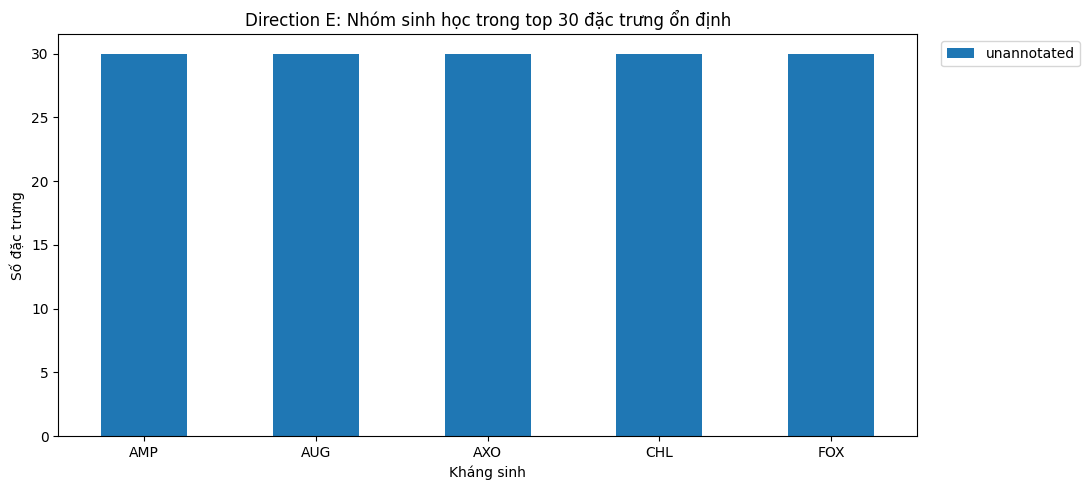

Đã lưu hình: /content/salmonella_direction_E/outputs/direction_E_top30_category_summary.png


In [ ]:
# ============================================================
# 11. CATEGORY SUMMARY
# ============================================================

category_summary_stable = (
    top_stable.groupby(["drug", "category"])
    .size()
    .reset_index(name="n_features")
)
category_summary_stable.to_csv(OUT_DIR / f"direction_E_top{TOP_N_FEATURES}_stable_category_summary.csv", index=False)
display(category_summary_stable)

# Vẽ stacked bar đơn giản
pivot = category_summary_stable.pivot(index="drug", columns="category", values="n_features").fillna(0)
ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 5))
plt.title(f"Direction E: Nhóm sinh học trong top {TOP_N_FEATURES} đặc trưng ổn định")
plt.ylabel("Số đặc trưng")
plt.xlabel("Kháng sinh")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig_path = OUT_DIR / f"direction_E_top{TOP_N_FEATURES}_category_summary.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Đã lưu hình:", fig_path)


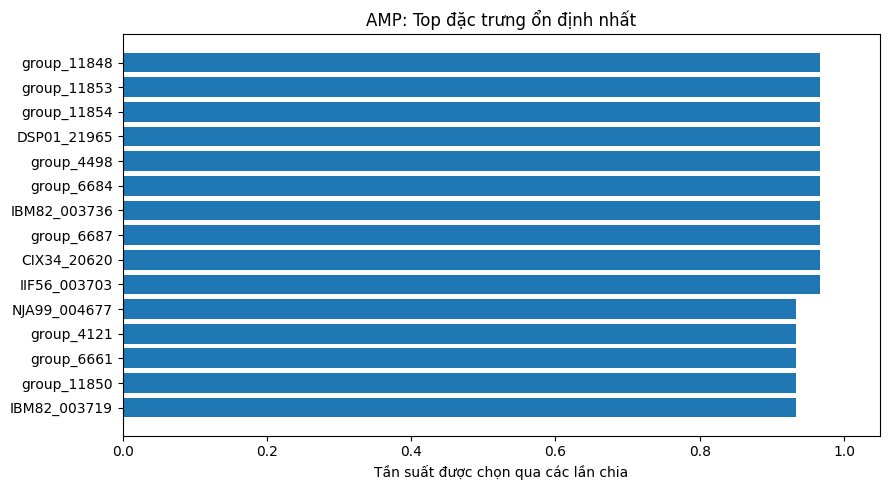

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AMP_top15_stable_frequency.png


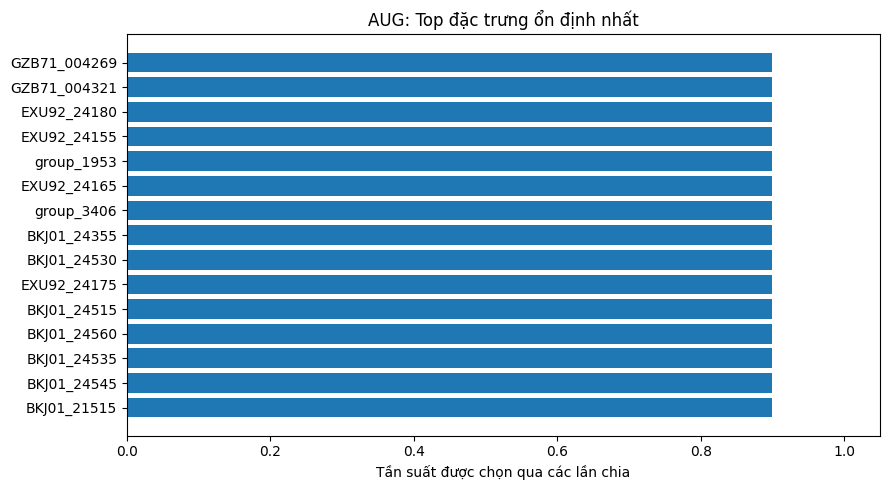

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AUG_top15_stable_frequency.png


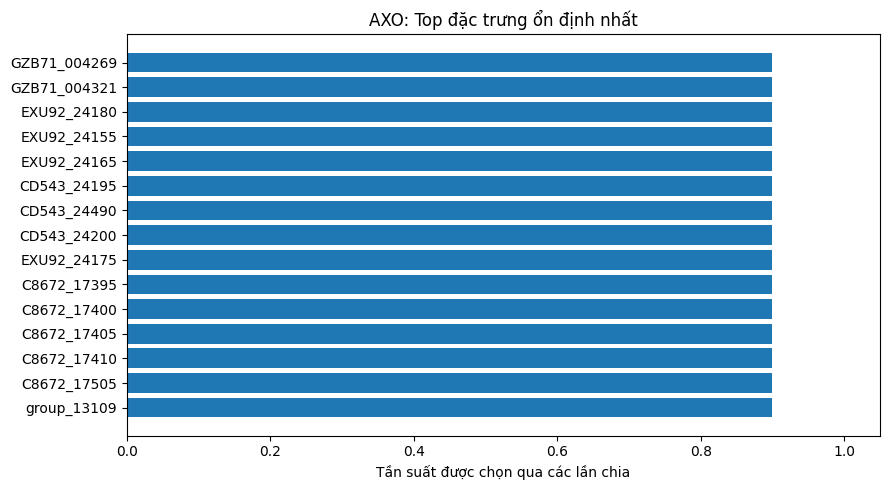

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AXO_top15_stable_frequency.png


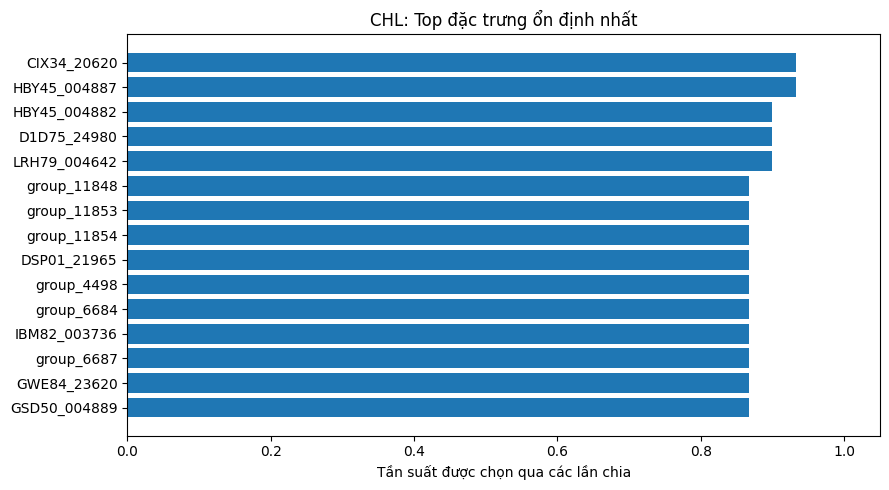

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_CHL_top15_stable_frequency.png


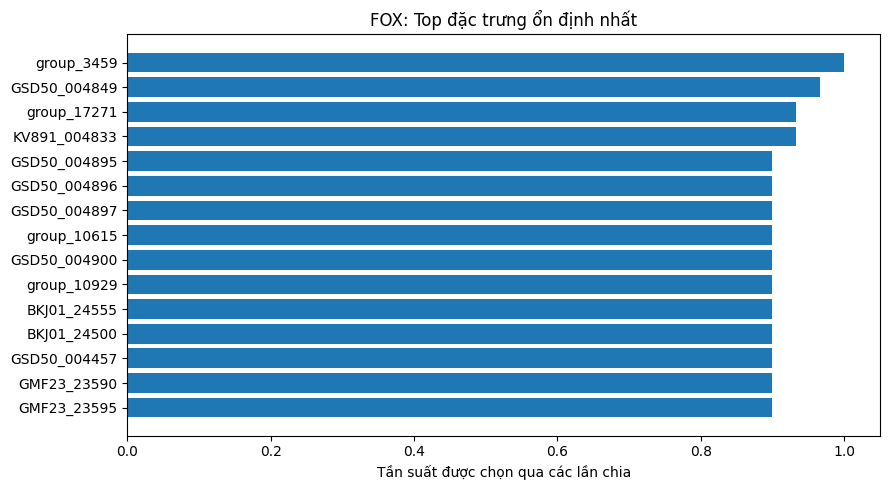

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_FOX_top15_stable_frequency.png


In [ ]:
# ============================================================
# 12. VẼ TOP FEATURE FREQUENCY THEO TỪNG THUỐC
# ============================================================

for drug in DRUGS:
    sub = stable_all[stable_all["drug"] == drug].head(15).copy()
    # label hiển thị: feature + category rút gọn
    sub["label"] = sub["feature"].astype(str)
    plt.figure(figsize=(9, 5))
    plt.barh(sub["label"][::-1], sub["selected_frequency"][::-1])
    plt.xlim(0, 1.05)
    plt.xlabel("Tần suất được chọn qua các lần chia")
    plt.title(f"{drug}: Top đặc trưng ổn định nhất")
    plt.tight_layout()
    path = OUT_DIR / f"direction_E_{drug}_top15_stable_frequency.png"
    plt.savefig(path, dpi=200)
    plt.show()
    print("Đã lưu:", path)


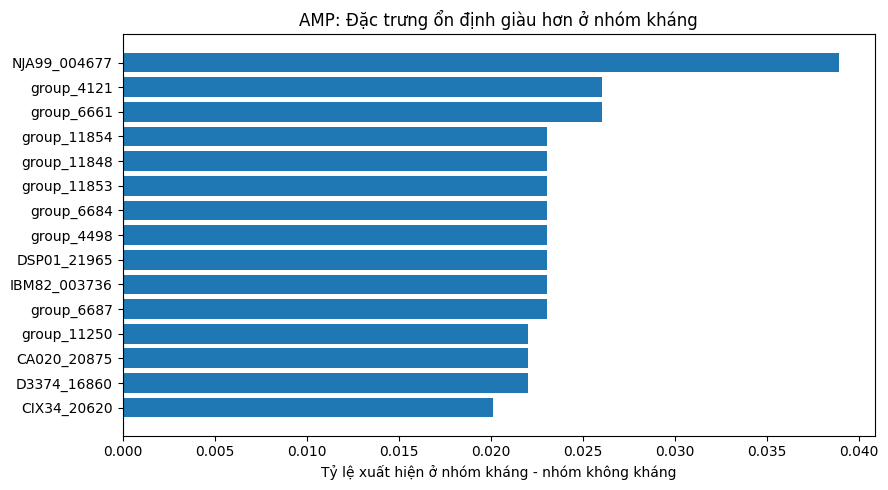

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AMP_top15_enrichment.png


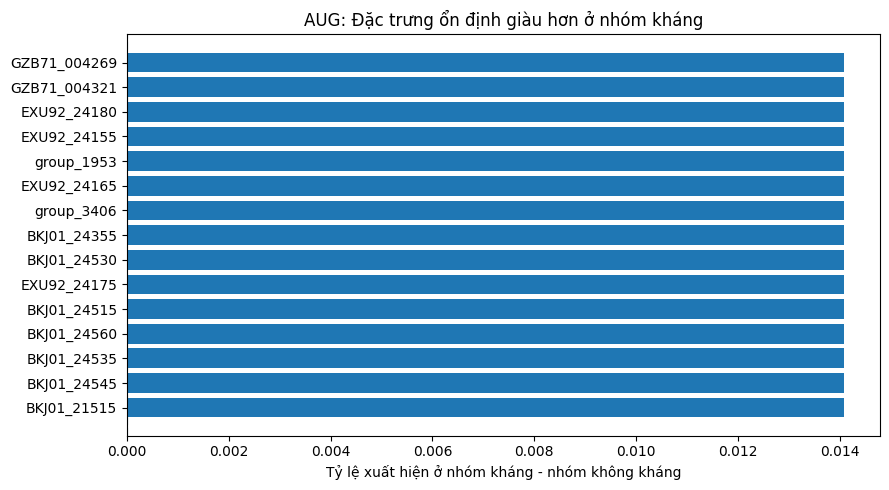

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AUG_top15_enrichment.png


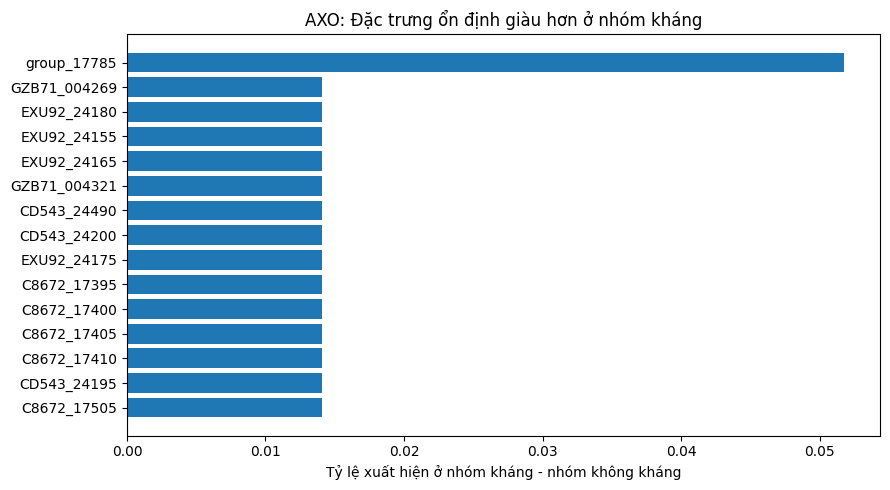

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_AXO_top15_enrichment.png


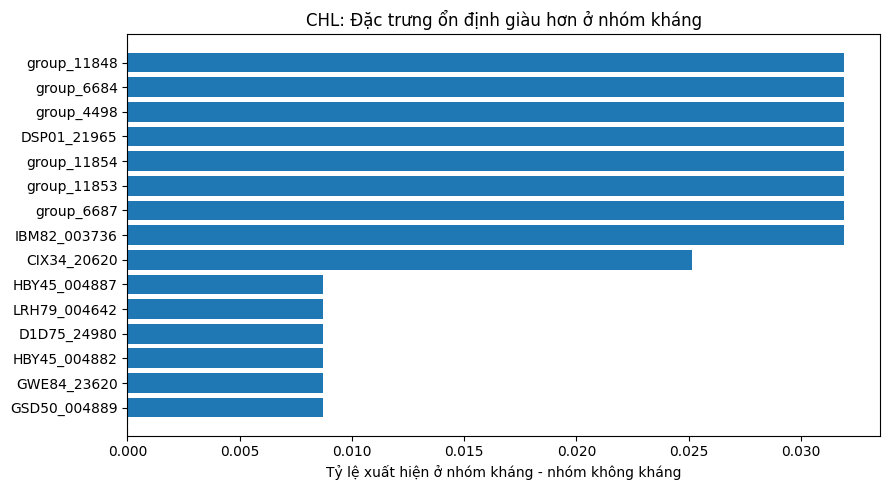

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_CHL_top15_enrichment.png


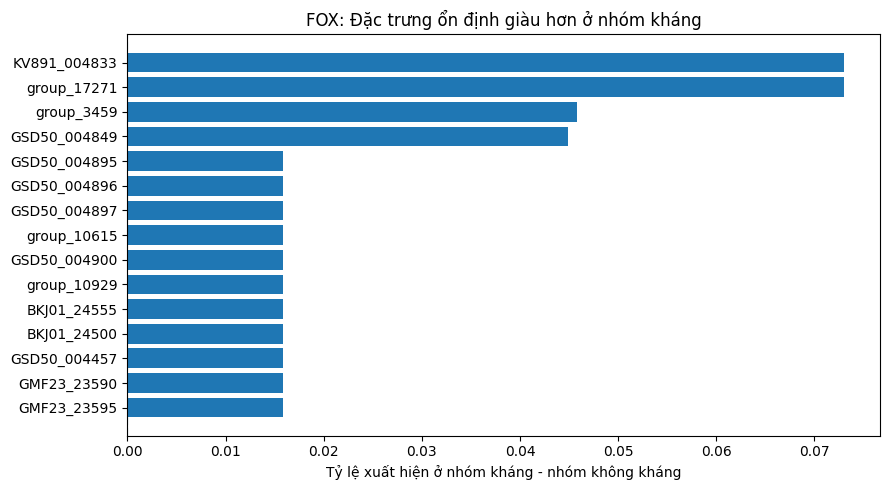

Đã lưu: /content/salmonella_direction_E/outputs/direction_E_FOX_top15_enrichment.png


In [ ]:
# ============================================================
# 13. VẼ ENRICHMENT TOP FEATURES
# ============================================================

for drug in DRUGS:
    sub = enrich_df[enrich_df["drug"] == drug].copy()
    sub = sub.sort_values("prevalence_diff_R_minus_nonR", ascending=False).head(15)
    if sub.empty:
        continue
    plt.figure(figsize=(9, 5))
    plt.barh(sub["feature"][::-1], sub["prevalence_diff_R_minus_nonR"][::-1])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Tỷ lệ xuất hiện ở nhóm kháng - nhóm không kháng")
    plt.title(f"{drug}: Đặc trưng ổn định giàu hơn ở nhóm kháng")
    plt.tight_layout()
    path = OUT_DIR / f"direction_E_{drug}_top15_enrichment.png"
    plt.savefig(path, dpi=200)
    plt.show()
    print("Đã lưu:", path)


## 10. So sánh với top 5 đặc trưng trong phụ lục bài báo

Phần này dùng các đặc trưng được phụ lục nêu rõ như CMY-2, TEM-1, floR, sul2... để kiểm tra xem chúng có nằm trong nhóm đặc trưng ổn định hay không.


In [ ]:
# ============================================================
# 14. SO SÁNH VỚI FEATURES NỔI BẬT TRONG PHỤ LỤC
# ============================================================

paper_top_features = {
    "AMP": ["GXG79_15935", "GXH02_05140", "FKE51_24750", "CKP39_24515", "GRX98_004990"],
    "AUG": ["GXG79_15935", "GXH02_05140", "FKE51_24750", "EEK86_04735", "snp581705"],
    "AXO": ["FKE51_24750", "sugE", "merT", "merA", "HF382_003898"],
    "CHL": ["GXH02_05140", "HF382_002470", "HF382_003966", "floR", "GP118_004663"],
    "FOX": ["FKE51_24750", "sugE", "FER41_22475", "CYN48_22375", "GY345_004353"],
}

compare_rows = []
for drug, feats in paper_top_features.items():
    stable_set = set(stable_all[stable_all["drug"] == drug]["feature"])
    top_stable_set = set(top_stable[top_stable["drug"] == drug]["feature"])
    ready_set = set(ready_feature_names.get(drug, []))
    for feat in feats:
        ann, src = lookup_annotation(feat)
        stable_count = 0
        stable_freq = 0
        tmp = stable_all[(stable_all["drug"] == drug) & (stable_all["feature"] == feat)]
        if len(tmp) > 0:
            stable_count = int(tmp.iloc[0]["selected_count"])
            stable_freq = float(tmp.iloc[0]["selected_frequency"])
        compare_rows.append({
            "drug": drug,
            "paper_feature": feat,
            "annotation": ann,
            "category": categorize_feature(feat, ann),
            "in_ready50": feat in ready_set,
            f"in_top{TOP_N_FEATURES}_stable": feat in top_stable_set,
            "selected_count_in_stability_run": stable_count,
            "selected_frequency_in_stability_run": stable_freq,
        })

paper_compare = pd.DataFrame(compare_rows)
paper_compare.to_csv(OUT_DIR / "direction_E_compare_paper_top5_with_stable_features.csv", index=False)
display(paper_compare)


,drug,paper_feature,annotation,category,in_ready50,in_top30_stable,selected_count_in_stability_run,selected_frequency_in_stability_run
0,AMP,GXG79_15935,Bacteriophage tail tape measure protein,mobile_element_or_lineage_context,True,False,0,0
1,AMP,GXH02_05140,Bacteriophage tail protein,mobile_element_or_lineage_context,True,False,0,0
2,AMP,FKE51_24750,C-class beta-lactamase CMY-2,known_or_plausible_resistance,True,False,0,0
3,AMP,CKP39_24515,A-class broad-spectrum beta-lactamase TEM-1,known_or_plausible_resistance,True,False,0,0
4,AMP,GRX98_004990,Recombinase family protein,mobile_element_or_lineage_context,True,False,0,0
5,AUG,GXG79_15935,Bacteriophage tail tape measure protein,mobile_element_or_lineage_context,True,False,0,0
6,AUG,GXH02_05140,Bacteriophage tail protein,mobile_element_or_lineage_context,True,False,0,0
7,AUG,FKE51_24750,C-class beta-lactamase CMY-2,known_or_plausible_resistance,True,False,0,0
8,AUG,EEK86_04735,IS1380-like element ISEc9 family transposase,mobile_element_or_lineage_context,True,False,0,0
9,AUG,snp581705,,unannotated,False,False,0,0


## 11. Kết luận tự động cho Direction E

In [ ]:
# ============================================================
# 15. AUTO CONCLUSION
# ============================================================

lines = []
lines.append("# AUTO CONCLUSION — DIRECTION E")
lines.append("")
lines.append("## Mục tiêu")
lines.append("Direction E tập trung vào diễn giải sinh học các đặc trưng quan trọng, thay vì chạy thêm mô hình phức tạp.")
lines.append("")
lines.append("## Dữ liệu")
lines.append(f"- Số mẫu: {len(labels)}.")
lines.append(f"- Số đặc trưng gen phụ dùng để chọn lại: {X_accessory.shape[1]}.")
lines.append(f"- Số lần chia dữ liệu để lấy đặc trưng ổn định: {N_REPEATS}.")
lines.append(f"- Số đặc trưng chọn mỗi lần: {K_STABLE}.")
lines.append("")
lines.append("## Kết quả chú giải")
for drug in DRUGS:
    sub = top_stable[top_stable["drug"] == drug]
    n_annot = int((sub["annotation"].fillna("") != "").sum())
    n_res = int((sub["category"] == "known_or_plausible_resistance").sum())
    n_mobile = int((sub["category"] == "mobile_element_or_lineage_context").sum())
    n_unknown = int(sub["category"].isin(["unannotated", "hypothetical_or_unknown"]).sum())
    lines.append(f"- {drug}: trong top {TOP_N_FEATURES} đặc trưng ổn định có {n_annot} đặc trưng có chú giải, {n_res} liên quan kháng thuốc rõ/khả dĩ, {n_mobile} liên quan vùng di động/dòng, {n_unknown} chưa rõ hoặc chưa chú giải.")
lines.append("")
lines.append("## Diễn giải")
lines.append("- Nếu đặc trưng ổn định thuộc nhóm beta-lactamase, TEM, CMY, floR, sul2 hoặc efflux, có thể xem là tín hiệu sinh học liên quan kháng thuốc hoặc đồng kháng.")
lines.append("- Nếu đặc trưng ổn định thuộc nhóm phage, transposase, recombinase hoặc plasmid, cần diễn giải cẩn thận vì đó có thể là tín hiệu vùng di động hoặc dấu hiệu dòng vi khuẩn, không nhất thiết là cơ chế kháng thuốc trực tiếp.")
lines.append("- Nếu đặc trưng chưa có chú giải, không nên kết luận cơ chế; nên xem đó là ứng viên cần tra cứu thêm.")
lines.append("")
lines.append("## Kết luận ngắn")
lines.append("Direction E giúp chuyển câu chuyện từ 'mô hình dự đoán tốt' sang 'mô hình dựa vào những tín hiệu sinh học nào'. Phần chú giải hiện có thể xác nhận một số marker kháng thuốc đã biết, nhưng vẫn cần bổ sung annotation đầy đủ hơn cho nhiều đặc trưng ổn định.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUT_DIR / "AUTO_CONCLUSION_DIRECTION_E.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)


# AUTO CONCLUSION — DIRECTION E

## Mục tiêu
Direction E tập trung vào diễn giải sinh học các đặc trưng quan trọng, thay vì chạy thêm mô hình phức tạp.

## Dữ liệu
- Số mẫu: 1167.
- Số đặc trưng gen phụ dùng để chọn lại: 18125.
- Số lần chia dữ liệu để lấy đặc trưng ổn định: 30.
- Số đặc trưng chọn mỗi lần: 200.

## Kết quả chú giải
- AMP: trong top 30 đặc trưng ổn định có 0 đặc trưng có chú giải, 0 liên quan kháng thuốc rõ/khả dĩ, 0 liên quan vùng di động/dòng, 30 chưa rõ hoặc chưa chú giải.
- AUG: trong top 30 đặc trưng ổn định có 0 đặc trưng có chú giải, 0 liên quan kháng thuốc rõ/khả dĩ, 0 liên quan vùng di động/dòng, 30 chưa rõ hoặc chưa chú giải.
- AXO: trong top 30 đặc trưng ổn định có 0 đặc trưng có chú giải, 0 liên quan kháng thuốc rõ/khả dĩ, 0 liên quan vùng di động/dòng, 30 chưa rõ hoặc chưa chú giải.
- CHL: trong top 30 đặc trưng ổn định có 0 đặc trưng có chú giải, 0 liên quan kháng thuốc rõ/khả dĩ, 0 liên quan vùng di động/dòng, 30 chưa rõ hoặc chưa chú giải.
- FOX: trong 

In [ ]:
# ============================================================
# 16. NÉN OUTPUT ĐỂ TẢI VỀ
# ============================================================

zip_path = BASE_DIR / "salmonella_direction_E_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print("Đã nén output:", zip_path)
print("Các file output:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)


Đã nén output: /content/salmonella_direction_E/salmonella_direction_E_outputs.zip
Các file output:
- AUTO_CONCLUSION_DIRECTION_E.md
- direction_E_AMP_top15_enrichment.png
- direction_E_AMP_top15_stable_frequency.png
- direction_E_AUG_top15_enrichment.png
- direction_E_AUG_top15_stable_frequency.png
- direction_E_AXO_top15_enrichment.png
- direction_E_AXO_top15_stable_frequency.png
- direction_E_CHL_top15_enrichment.png
- direction_E_CHL_top15_stable_frequency.png
- direction_E_FOX_top15_enrichment.png
- direction_E_FOX_top15_stable_frequency.png
- direction_E_compare_paper_top5_with_stable_features.csv
- direction_E_dataset_label_summary.csv
- direction_E_ready50_category_summary.csv
- direction_E_ready50_features_annotated.csv
- direction_E_stable_features_annotated_all.csv
- direction_E_top30_category_summary.png
- direction_E_top30_stable_category_summary.csv
- direction_E_top30_stable_feature_enrichment.csv
- direction_E_top30_stable_features_annotated.csv


## Gợi ý đọc kết quả

Sau khi chạy xong, xem các file chính:

```text
direction_E_top30_stable_features_annotated.csv
direction_E_top30_stable_feature_enrichment.csv
direction_E_top30_stable_category_summary.csv
direction_E_compare_paper_top5_with_stable_features.csv
AUTO_CONCLUSION_DIRECTION_E.md
```

Nếu phần Roary annotation vẫn ít, dùng bảng `direction_E_top30_stable_features_annotated.csv` để tra cứu thủ công thêm các gen chưa rõ.
